In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

In [2]:
cursor.execute("""
CREATE TABLE passengers (
    id          INTEGER PRIMARY KEY,
    first_name  TEXT NOT NULL,
    last_name   TEXT NOT NULL,
    email       TEXT UNIQUE,
    nationality TEXT
);
""")

In [3]:
passengers_data = [
    (1, 'Lucas',   'Moreau',   'lucas.moreau@email.fr',    'Française'),
    (2, 'Emma',    'Dubois',   'emma.dubois@email.fr',     'Française'),
    (3, 'Noah',    'Leroy',    'noah.leroy@email.fr',      'Française'),
    (4, 'Sofia',   'Rossi',    'sofia.rossi@email.it',     'Italienne'),
    (5, 'Liam',    'Smith',    'liam.smith@email.uk',      'Britannique'),
    (6, 'Mia',     'Müller',   'mia.muller@email.de',      'Allemande'),
    (7, 'Hugo',    'Bernard',  'hugo.bernard@email.fr',    'Française'),
    (8, 'Camille', 'Thomas',   'camille.thomas@email.fr',  'Française'),
    (9, 'Alice',   'Martin',   'alice.martin@email.fr',    'Française'),
    (10,'Carlos',  'Garcia',   'carlos.garcia@email.es',   'Espagnole'),
    (11,'Jade',    'Petit',    'jade.petit@email.fr',      'Française'),
    (12,'Omar',    'Hassan',   'omar.hassan@email.ma',     'Marocaine'),
    (13,'Elena',   'Popescu',  'elena.popescu@email.ro',   'Roumaine'),
    (14,'Antoine', 'Garnier',  'antoine.garnier@email.fr', 'Française'),
    (15,'Yako',    'Tanaka',   'yuki.tanaka@email.jp',     'Japonaise'),
]

In [4]:
cursor.executemany("INSERT INTO passengers VALUES (?,?,?,?,?)", passengers_data)
conn.commit()

cursor.execute("SELECT COUNT(*) FROM passengers")
count = cursor.fetchone()[0]
assert count == 15, f"La table passengers devrait contenir 15 passagers, elle en a {count}"
print(f"Table passengers créée et remplie avec {count} passagers !")

Table passengers créée et remplie avec 15 passagers !


In [5]:
cursor.execute("""
CREATE TABLE flights ( 
    id INTEGER PRIMARY KEY,
    flight_number TEXT NOT NULL, 
    origin TEXT NOT NULL, 
    destination TEXT NOT NULL,
    departure_time TEXT NOT NULL,
    arrival_time TEXT NOT NULL,
    aircraft TEXT,
    capacity INTEGER,
    price_eur REAL
);
""")

In [6]:
flights_data = [
    (1,  'AF1234', 'Nice',      'Paris CDG',    '2026-07-01 07:00', '2026-07-01 08:30', 'Airbus A320', 180, 89.0),
    (2,  'AF1235', 'Paris CDG', 'Nice',          '2026-07-01 19:00', '2026-07-01 20:30', 'Airbus A320', 180, 95.0),
    (3,  'EZ4501', 'Nice',      'Londres',       '2026-07-02 06:30', '2026-07-02 08:15', 'Airbus A319', 156, 120.0),
    (4,  'EZ4502', 'Nice',      'Amsterdam',     '2026-07-02 09:00', '2026-07-02 11:30', 'Airbus A319', 156, 135.0),
    (5,  'VY6010', 'Nice',      'Barcelone',     '2026-07-03 11:00', '2026-07-03 12:45', 'Boeing 737',  189, 78.0),
    (6,  'AF5501', 'Nice',      'New York JFK',  '2026-07-04 13:00', '2026-07-04 22:30', 'Boeing 777',  350, 650.0),
    (7,  'LH2201', 'Nice',      'Francfort',     '2026-07-05 08:00', '2026-07-05 09:45', 'Airbus A320', 180, 112.0),
    (8,  'IB3301', 'Nice',      'Madrid',        '2026-07-05 14:00', '2026-07-05 16:00', 'Boeing 737',  189, 99.0),
    (9,  'AF1236', 'Nice',      'Paris CDG',     '2026-07-06 18:00', '2026-07-06 19:30', 'Airbus A320', 180, 105.0),
    (10, 'U24401', 'Nice',      'Athènes',       '2026-07-07 10:00', '2026-07-07 13:30', 'Boeing 737',  189, 145.0),
    (11, 'FR7701', 'Nice',      'Dublin',        '2026-07-08 07:30', '2026-07-08 10:00', 'Boeing 737',  189, 89.0),
    (12, 'AF1237', 'Paris CDG', 'Nice',          '2026-07-08 20:00', '2026-07-08 21:30', 'Airbus A321', 220, 88.0),
    (13, 'EZ4503', 'Nice',      'Berlin',        '2026-07-09 12:00', '2026-07-09 14:15', 'Airbus A319', 156, 118.0),
    (14, 'AF5502', 'Nice',      'New York JFK',  '2026-07-10 13:00', '2026-07-10 22:30', 'Boeing 777',  350, 680.0),
    (15, 'TK8801', 'Nice',      'Istanbul',      '2026-07-11 09:00', '2026-07-11 12:30', 'Boeing 737',  189, 160.0),
]

In [7]:
cursor.executemany("INSERT INTO flights VALUES (?,?,?,?,?,?,?,?,?)", flights_data)
conn.commit()

cursor.execute("PRAGMA table_info(flights)")
columns = cursor.fetchall()
schema = {col[1]: col[2] for col in columns}
expected_schema = {
    'id': 'INTEGER', 'flight_number': 'TEXT', 'origin': 'TEXT', 'destination': 'TEXT',
    'departure_time': 'TEXT', 'arrival_time': 'TEXT', 'aircraft': 'TEXT',
    'capacity': 'INTEGER', 'price_eur': 'REAL',
}
assert schema == expected_schema, f"Le schéma ne correspond pas. Attendu : {expected_schema}, obtenu : {schema}"

not_null_columns = {col[1] for col in columns if col[3] == 1}
expected_not_null = {'flight_number', 'origin', 'destination', 'departure_time', 'arrival_time'}
assert not_null_columns == expected_not_null, \
    f"Les colonnes NOT NULL attendues sont {expected_not_null}, tu as : {not_null_columns}"

cursor.execute("SELECT COUNT(*) FROM flights")
count = cursor.fetchone()[0]
assert count == 15, f"La table flights devrait contenir 15 vols, elle en a {count}"
print(f"Table flights créée et remplie avec {count} vols, exercice validé !")

Table flights créée et remplie avec 15 vols, exercice validé !


In [8]:
cursor.execute("""
CREATE TABLE bookings (
    id INTEGER PRIMARY KEY,
    passenger_id INTEGER REFERENCES passengers(id),
    flight_id INTEGER REFERENCES flights(id),
    booking_date TEXT,
    seat_class TEXT CHECK (seat_class IN ('economy', 'business', 'first')),
    seat_number TEXT,
    status TEXT CHECK (status IN ('confirmed', 'cancelled', 'pending'))
);
""")

In [9]:
bookings_data = [
    (1,  1,  1,  '2026-06-01', 'economy',  '14A', 'confirmed'),
    (2,  2,  1,  '2026-06-02', 'business', '2C',  'confirmed'),
    (4,  4,  5,  '2026-06-05', 'economy',  '18C', 'confirmed'),
    (5,  5,  3,  '2026-06-06', 'business', '1A',  'confirmed'),
    (6,  6,  7,  '2026-06-07', 'economy',  '31D', 'confirmed'),
    (7,  7,  6,  '2026-06-08', 'first',    '1A',  'confirmed'),
    (8,  8,  6,  '2026-06-09', 'business', '3B',  'confirmed'),
    (9,  9,  9,  '2026-06-10', 'economy',  '25A', 'confirmed'),
    (10, 10, 5,  '2026-06-11', 'economy',  '17B', 'cancelled'),
    (11, 11, 10, '2026-06-12', 'economy',  '8C',  'confirmed'),
    (12, 12, 15, '2026-06-13', 'economy',  '11A', 'confirmed'),
    (13, 13, 4,  '2026-06-14', 'economy',  '29B', 'pending'),
    (14, 14, 2,  '2026-06-15', 'business', '4A',  'confirmed'),
    (15, 15, 6,  '2026-06-16', 'first',    '2A',  'confirmed'),
    (16, 1,  9,  '2026-06-17', 'economy',  '33C', 'confirmed'),
    (17, 2,  10, '2026-06-18', 'economy',  '15A', 'cancelled'),
    (18, 5,  6,  '2026-06-19', 'business', '5B',  'confirmed'),
    (19, 7,  14, '2026-06-20', 'first',    '1B',  'confirmed'),
    (20, 9,  11, '2026-06-21', 'economy',  '22D', 'confirmed'),
]

In [10]:
cursor.executemany("INSERT INTO bookings VALUES (?,?,?,?,?,?,?)", bookings_data)
conn.commit()

cursor.execute("PRAGMA table_info(bookings)")
schema = {col[1]: col[2] for col in cursor.fetchall()}
expected_schema = {
    'id': 'INTEGER', 'passenger_id': 'INTEGER', 'flight_id': 'INTEGER',
    'booking_date': 'TEXT', 'seat_class': 'TEXT', 'seat_number': 'TEXT', 'status': 'TEXT',
}
assert schema == expected_schema, f"Le schéma ne correspond pas. Attendu : {expected_schema}, obtenu : {schema}"

try:
    cursor.execute("INSERT INTO bookings VALUES (999, 1, 1, '2026-06-30', 'premium', '1A', 'confirmed')")
    raise AssertionError("La contrainte CHECK sur seat_class ne fonctionne pas : 'premium' a été accepté")
except sqlite3.IntegrityError:
    pass

cursor.execute("SELECT COUNT(*) FROM bookings")
count = cursor.fetchone()[0]
assert count == 19, f"La table bookings devrait contenir 19 réservations, elle en a {count}"

print("Base de données complète.")
print(f"  {len(passengers_data)} passagers")
print(f"  {len(flights_data)} vols")
print(f"  {len(bookings_data)} réservations")

Base de données complète.
  15 passagers
  15 vols
  19 réservations


In [11]:
def query(sql):
    """Execute a SQL query and return the result as a pandas DataFrame."""
    return pd.read_sql_query(sql, conn)

In [12]:
result = query("""
SELECT flight_number, destination, departure_time, price_eur
FROM flights
WHERE origin = 'Nice'
ORDER BY departure_time;
""")

display(result)

,flight_number,destination,departure_time,price_eur
0,AF1234,Paris CDG,2026-07-01 07:00,89.0
1,EZ4501,Londres,2026-07-02 06:30,120.0
2,EZ4502,Amsterdam,2026-07-02 09:00,135.0
3,VY6010,Barcelone,2026-07-03 11:00,78.0
4,AF5501,New York JFK,2026-07-04 13:00,650.0
5,LH2201,Francfort,2026-07-05 08:00,112.0
6,IB3301,Madrid,2026-07-05 14:00,99.0
7,AF1236,Paris CDG,2026-07-06 18:00,105.0
8,U24401,Athènes,2026-07-07 10:00,145.0
9,FR7701,Dublin,2026-07-08 07:30,89.0


In [13]:
result = query("""
SELECT flight_number, destination, departure_time, price_eur
FROM flights
WHERE origin = 'Nice'
ORDER BY departure_time;
""")

display(result)

,flight_number,destination,departure_time,price_eur
0,AF1234,Paris CDG,2026-07-01 07:00,89.0
1,EZ4501,Londres,2026-07-02 06:30,120.0
2,EZ4502,Amsterdam,2026-07-02 09:00,135.0
3,VY6010,Barcelone,2026-07-03 11:00,78.0
4,AF5501,New York JFK,2026-07-04 13:00,650.0
5,LH2201,Francfort,2026-07-05 08:00,112.0
6,IB3301,Madrid,2026-07-05 14:00,99.0
7,AF1236,Paris CDG,2026-07-06 18:00,105.0
8,U24401,Athènes,2026-07-07 10:00,145.0
9,FR7701,Dublin,2026-07-08 07:30,89.0


In [14]:
result = query("""
SELECT flight_number, destination, price_eur
FROM flights 
WHERE price_eur < 100
ORDER BY price_eur;
""")
display(result)

,flight_number,destination,price_eur
0,VY6010,Barcelone,78.0
1,AF1237,Nice,88.0
2,AF1234,Paris CDG,89.0
3,FR7701,Dublin,89.0
4,AF1235,Nice,95.0
5,IB3301,Madrid,99.0


In [15]:
result = query("""
SELECT * FROM passengers WHERE last_name = 'Tanaka';
""")
display(result)

,id,first_name,last_name,email,nationality
0,15,Yako,Tanaka,yuki.tanaka@email.jp,Japonaise


In [16]:
result = query("""
SELECT status, COUNT(*) AS count
FROM bookings
GROUP BY status
ORDER BY count DESC;
""")
display(result)

,status,count
0,confirmed,16
1,cancelled,2
2,pending,1


In [17]:
result = query("""
SELECT 
    flights.destination,
    SUM(flights.price_eur) AS total_revenue,
    COUNT(bookings.id) AS nb_bookings
FROM bookings
JOIN flights ON bookings.flight_id 
WHERE bookings.status = 'confirmed'
GROUP BY flights.destination
ORDER BY total_revenue DESC;
""")
display(result)

,destination,total_revenue,nb_bookings
0,New York JFK,21280.0,32
1,Paris CDG,3104.0,32
2,Nice,2928.0,32
3,Istanbul,2560.0,16
4,Athènes,2320.0,16
5,Amsterdam,2160.0,16
6,Londres,1920.0,16
7,Berlin,1888.0,16
8,Francfort,1792.0,16
9,Madrid,1584.0,16


In [18]:
result = query("""
SELECT 
    flights.destination,
    SUM(flights.price_eur) AS total_revenue,
    COUNT(bookings.id) AS nb_bookings
FROM bookings
JOIN flights ON bookings.flight_id 
WHERE bookings.status = 'confirmed'
GROUP BY flights.destination
HAVING COUNT(bookings.id) > 1
ORDER BY total_revenue DESC;
""")
display(result)

,destination,total_revenue,nb_bookings
0,New York JFK,21280.0,32
1,Paris CDG,3104.0,32
2,Nice,2928.0,32
3,Istanbul,2560.0,16
4,Athènes,2320.0,16
5,Amsterdam,2160.0,16
6,Londres,1920.0,16
7,Berlin,1888.0,16
8,Francfort,1792.0,16
9,Madrid,1584.0,16


In [19]:
result = query("""
SELECT 
    passengers.first_name AS first_name,
    passengers.last_name AS last_name,
    bookings.seat_class AS seat_class,
    bookings.seat_number AS seat_number
FROM passengers
JOIN bookings ON passengers.id = bookings.passenger_id 
JOIN flights ON flights.id = bookings.flight_id
WHERE bookings.status = 'confirmed' AND flights.flight_number ='AF5501';
""")
display(result)

,first_name,last_name,seat_class,seat_number
0,Hugo,Bernard,first,1A
1,Camille,Thomas,business,3B
2,Yako,Tanaka,first,2A
3,Liam,Smith,business,5B


In [20]:
result = query("""
SELECT 
    passengers.last_name AS last_name, 
    passengers.first_name AS first_name
FROM passengers
LEFT JOIN bookings ON passengers.id = bookings.passenger_id
WHERE bookings.passenger_id IS NULL;
""")
display(result)

,last_name,first_name
0,Leroy,Noah


In [21]:
result = query("""
SELECT 
    flight_number, destination, price_eur
FROM flights
WHERE price_eur > (SELECT AVG(price_eur) FROM flights);
""")
display(result)

,flight_number,destination,price_eur
0,AF5501,New York JFK,650.0
1,AF5502,New York JFK,680.0


In [22]:
result = query("""
SELECT 
    passengers.last_name AS last_name,
    passengers.first_name AS first_name,
    COUNT(bookings.id) AS nb_bookings
FROM passengers
JOIN bookings ON bookings.passenger_id = passengers.id
GROUP BY passengers.id, passengers.last_name, passengers.first_name
HAVING nb_bookings > 1;
""")
display(result)

,last_name,first_name,nb_bookings
0,Moreau,Lucas,2
1,Dubois,Emma,2
2,Smith,Liam,2
3,Bernard,Hugo,2
4,Martin,Alice,2


,destination,total_revenue,nb_bookings
0,New York JFK,21280.0,32
1,Paris CDG,3104.0,32
2,Nice,2928.0,32
3,Istanbul,2560.0,16
4,Athènes,2320.0,16
5,Amsterdam,2160.0,16
6,Londres,1920.0,16
7,Berlin,1888.0,16
8,Francfort,1792.0,16
9,Madrid,1584.0,16


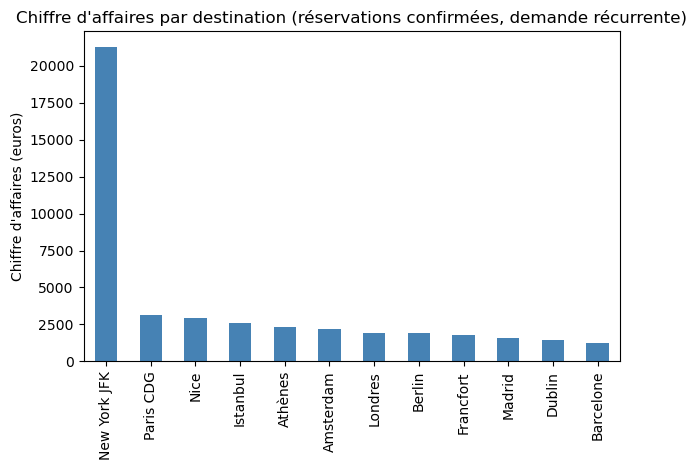

In [23]:
import matplotlib.pyplot as plt

result = query("""
SELECT 
    flights.destination,
    SUM(flights.price_eur) AS total_revenue,
    COUNT(bookings.id) AS nb_bookings
FROM bookings
JOIN flights ON bookings.flight_id 
WHERE bookings.status = 'confirmed'
GROUP BY flights.destination
HAVING COUNT(bookings.id) > 1
ORDER BY total_revenue DESC;
""")
display(result)

assert result.iloc[0]['destination'] == 'New York JFK', \
    f"La destination en tête devrait être New York JFK, tu as {result.iloc[0]['destination']}"

result.plot(kind='bar', x='destination', y='total_revenue', legend=False, color='steelblue')
plt.title("Chiffre d'affaires par destination (réservations confirmées, demande récurrente)")
plt.ylabel("Chiffre d'affaires (euros)")
plt.xlabel("")
plt.tight_layout()
plt.show()